# 📊 Notebook 05 Evaluasi: IndoRoBERTa-base vs. XLM-RoBERTa-large
### Aspect-Based Sentiment Analysis (ABSA) Kendaraan Listrik (EV) di Indonesia

Notebook ini menyajikan evaluasi komparatif mendalam antara dua arsitektur transformer:
1. **IndoRoBERTa-base (110M)** (`indolem/indobert-base-uncased`) - Baseline Local Model
2. **XLM-RoBERTa-large (550M)** (`xlm-roberta-large`) - Winner Multi-Head SOTA Model

---

## 🛠️ 1. Metodologi Training & Hyperparameter
Proses training dilakukan dengan **5-Fold Stratified Cross-Validation** pada dataset Gold Standard (954 komentar YouTube berlabel aspek & sentimen).

| Parameter / Konfigurasi | IndoRoBERTa-base | XLM-RoBERTa-large |
| :--- | :--- | :--- |
| **Jumlah Parameter** | ~110 Juta (110M) | ~550 Juta (550M) |
| **Pretrained Model Name** | `indolem/indobert-base-uncased` | `xlm-roberta-large` |
| **Max Sequence Length** | 128 Tokens | 128 Tokens |
| **Batch Size per GPU** | 16 | 8 |
| **Gradient Accumulation** | 1 (Effective Batch = 16) | 2 (Effective Batch = 16) |
| **Learning Rate** | $2 \times 10^{-5}$ ($2e-5$) | $1.5 \times 10^{-5}$ ($1.5e-5$) |
| **Optimizer & Weight Decay** | AdamW (`weight_decay = 0.01`) | AdamW (`weight_decay = 0.01`) |
| **Learning Rate Scheduler** | Cosine Schedule (10% Warmup) | Cosine Schedule (10% Warmup) |
| **Loss Function** | Multi-Head Focal Loss ($\gamma=1.5$) + Dynamic Inverse Class Weights | Multi-Head Focal Loss ($\gamma=1.5$) + Dynamic Inverse Class Weights |
| **Jumlah Epoch** | 20 Epochs / Fold | 20 Epochs / Fold |
| **Decision Thresholds** | `infra`: 0.5, `ekonomi`: 0.4, `kualitas`: 0.4, `purnajual`: 0.5 | `infra`: 0.5, `ekonomi`: 0.4, `kualitas`: 0.4, `purnajual`: 0.5 |

---

## 📐 2. Metodologi Perhitungan Evaluasi 4 Aspek
Evaluasi dilakukan secara independen pada **4 Aspek Evaluasi**:
1. 🏗️ **Infrastruktur (`infra`)**
2. 💰 **Ekonomi (`ekonomi`)**
3. 🚘 **Kualitas (`kualitas`)**
4. 🛠️ **Purna Jual (`purnajual`)**

Masing-masing aspek diklasifikasikan ke dalam 4 kelas sentimen: **NONE (0)**, **POSITIF (1)**, **NETRAL (2)**, dan **NEGATIF (3)**.

### Metrik yang Diukur:
- **Macro F1 (Active Sentiments):** Rata-rata Macro F1 khusus pada kelas aktif (Positif, Netral, Negatif), mengabaikan kelas mayoritas NONE. Metrik ini menjadi indikator utama untuk mengukur kemampuan model mendeteksi sentimen nyata.
  $$\text{Macro F1}_{active} = \frac{\text{F1}_{Positif} + \text{F1}_{Netral} + \text{F1}_{Negatif}}{3}$$
- **Macro F1 (All Classes):** Rata-rata Macro F1 pada seluruh 4 kelas (termasuk NONE).
  $$\text{Macro F1}_{all} = \frac{\text{F1}_{NONE} + \text{F1}_{Positif} + \text{F1}_{Netral} + \text{F1}_{Negatif}}{4}$$
- **Accuracy:** Persentase keakuratan prediksi dari total sampel pada aspek tersebut.
- **Aggregasi 5-Fold:** Dihitung mean (μ) dan standar deviasi (σ) dari 5 fold validation.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

# Setting plot style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8



In [2]:
# Define file paths
BASE_DIR = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".").resolve()

ITER03_JSON = BASE_DIR / "outputs" / "iter-03" / "model_comparison_metrics_5fold.json"
ITER04_JSON = BASE_DIR / "outputs" / "iter-04" / "xlmroberta_metrics_5fold.json"
CONFUSION_MATRIX_IMG = BASE_DIR / "outputs" / "iter-04" / "xlmroberta_confusion_matrices.png"
LEARNING_CURVES_IMG = BASE_DIR / "outputs" / "iter-04" / "xlmroberta_learning_curves.png"

print(f"📂 Loading IndoRoBERTa metrics from: {ITER03_JSON}")
with open(ITER03_JSON, encoding="utf-8") as f:
    data_iter03 = json.load(f)

print(f"📂 Loading XLM-RoBERTa metrics from: {ITER04_JSON}")
with open(ITER04_JSON, encoding="utf-8") as f:
    data_iter04 = json.load(f)

indoroberta_data = data_iter03["indoroberta_5fold"]
xlmroberta_data = data_iter04["xlmroberta_5fold"]

print("✅ Both model metric files loaded successfully!")



📂 Loading IndoRoBERTa metrics from: C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\usb_2026\outputs\iter-03\model_comparison_metrics_5fold.json
📂 Loading XLM-RoBERTa metrics from: C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\usb_2026\outputs\iter-04\xlmroberta_metrics_5fold.json
✅ Both model metric files loaded successfully!


In [3]:
# Extract overall metrics
def extract_model_summary(model_name, model_dict):
    active_f1s = [fold["overall"]["mean_macro_f1_active"] for fold in model_dict["folds"]]
    all_f1s = [fold["overall"].get("mean_macro_f1_all", np.nan) for fold in model_dict["folds"]]
    accuracies = [fold["overall"].get("mean_accuracy", np.nan) for fold in model_dict["folds"]]
    
    # Calculate all_f1s and accuracies if missing in raw fold dictionary
    if any(np.isnan(all_f1s)):
        all_f1s_calc = []
        accs_calc = []
        for fold in model_dict["folds"]:
            f1_all_fold = np.mean([fold["per_aspect"][asp]["f1_macro_all"] for asp in fold["per_aspect"]])
            acc_fold = np.mean([fold["per_aspect"][asp]["accuracy"] for asp in fold["per_aspect"]])
            all_f1s_calc.append(f1_all_fold)
            accs_calc.append(acc_fold)
        all_f1s = all_f1s_calc
        accuracies = accs_calc

    mean_act = float(np.mean(active_f1s))
    std_act = float(np.std(active_f1s))
    mean_all = float(np.mean(all_f1s))
    std_all = float(np.std(all_f1s))
    mean_acc = float(np.mean(accuracies))
    std_acc = float(np.std(accuracies))

    return {
        "Model": model_name,
        "Mean F1 Active": mean_act,
        "Std F1 Active": std_act,
        "Mean F1 All": mean_all,
        "Std F1 All": std_all,
        "Mean Accuracy": mean_acc,
        "Std Accuracy": std_acc,
        "Formatted F1 Active": f"{mean_act:.4f} ± {std_act:.4f}",
        "Formatted F1 All": f"{mean_all:.4f} ± {std_all:.4f}",
        "Formatted Accuracy": f"{mean_acc:.4f} ± {std_acc:.4f}"
    }

summary_indoroberta = extract_model_summary("IndoRoBERTa-base (110M)", indoroberta_data)
summary_xlmroberta = extract_model_summary("XLM-RoBERTa-large (550M)", xlmroberta_data)

df_summary = pd.DataFrame([summary_indoroberta, summary_xlmroberta])

print("🏆 PERBANDINGAN METRIK GLOBAL (5-FOLD CROSS-VALIDATION):")
display(df_summary[["Model", "Formatted F1 Active", "Formatted F1 All", "Formatted Accuracy"]])



🏆 PERBANDINGAN METRIK GLOBAL (5-FOLD CROSS-VALIDATION):


,Model,Formatted F1 Active,Formatted F1 All,Formatted Accuracy
0,IndoRoBERTa-base (110M),0.4820 ± 0.0245,0.5847 ± 0.0208,0.7937 ± 0.0100
1,XLM-RoBERTa-large (550M),0.5826 ± 0.0338,0.6666 ± 0.0264,0.8382 ± 0.0080


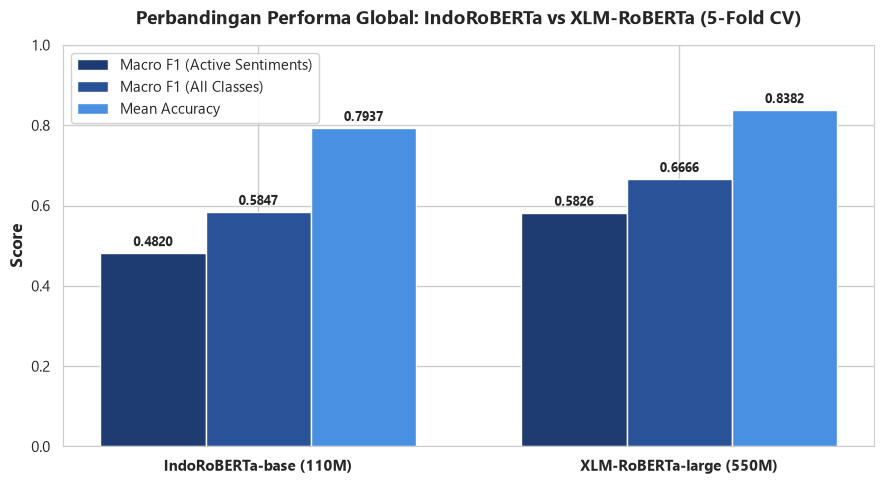

In [4]:
# Visualization of Overall Metrics Comparison
fig, ax = plt.subplots(figsize=(9, 5))

models = [summary_indoroberta["Model"], summary_xlmroberta["Model"]]
f1_active = [summary_indoroberta["Mean F1 Active"], summary_xlmroberta["Mean F1 Active"]]
f1_all = [summary_indoroberta["Mean F1 All"], summary_xlmroberta["Mean F1 All"]]
accuracy = [summary_indoroberta["Mean Accuracy"], summary_xlmroberta["Mean Accuracy"]]

x = np.arange(len(models))
width = 0.25

rects1 = ax.bar(x - width, f1_active, width, label='Macro F1 (Active Sentiments)', color='#1e3c72')
rects2 = ax.bar(x, f1_all, width, label='Macro F1 (All Classes)', color='#2a5298')
rects3 = ax.bar(x + width, accuracy, width, label='Mean Accuracy', color='#4a90e2')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Performa Global: IndoRoBERTa vs XLM-RoBERTa (5-Fold CV)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.set_ylim(0, 1.0)

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



In [5]:
# Per-Aspect Detailed Breakdown
aspects = ["infra", "ekonomi", "kualitas", "purnajual"]
aspect_names = {
    "infra": "Infrastruktur EV",
    "ekonomi": "Ekonomi & Harga",
    "kualitas": "Kualitas Produk",
    "purnajual": "Purna Jual"
}

aspect_metrics_list = []

for asp in aspects:
    for model_name, model_dict in [("IndoRoBERTa-base", indoroberta_data), ("XLM-RoBERTa-large", xlmroberta_data)]:
        f1_active = np.mean([fold["per_aspect"][asp]["f1_macro_active"] for fold in model_dict["folds"]])
        f1_all = np.mean([fold["per_aspect"][asp]["f1_macro_all"] for fold in model_dict["folds"]])
        acc = np.mean([fold["per_aspect"][asp]["accuracy"] for fold in model_dict["folds"]])
        prec = np.mean([fold["per_aspect"][asp]["precision_macro"] for fold in model_dict["folds"]])
        rec = np.mean([fold["per_aspect"][asp]["recall_macro"] for fold in model_dict["folds"]])
        
        aspect_metrics_list.append({
            "Aspek": aspect_names[asp],
            "Model": model_name,
            "F1 Active": f1_active,
            "F1 All": f1_all,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec
        })

df_aspects = pd.DataFrame(aspect_metrics_list)

print("📋 PERBANDINGAN HASIL PER-ASPEK:")
display(df_aspects)



📋 PERBANDINGAN HASIL PER-ASPEK:


,Aspek,Model,F1 Active,F1 All,Accuracy,Precision,Recall
0,Infrastruktur EV,IndoRoBERTa-base,0.454824,0.579325,0.890308,0.594561,0.579489
1,Infrastruktur EV,XLM-RoBERTa-large,0.506655,0.620792,0.904856,0.625087,0.628219
2,Ekonomi & Harga,IndoRoBERTa-base,0.510638,0.602030,0.737112,0.591276,0.620075
3,Ekonomi & Harga,XLM-RoBERTa-large,0.627487,0.696299,0.801004,0.683337,0.713653
4,Kualitas Produk,IndoRoBERTa-base,0.549017,0.615009,0.698614,0.612831,0.627971
5,Kualitas Produk,XLM-RoBERTa-large,0.631041,0.688939,0.764709,0.683603,0.699094
6,Purna Jual,IndoRoBERTa-base,0.413693,0.542472,0.848930,0.609899,0.515942
7,Purna Jual,XLM-RoBERTa-large,0.565071,0.660249,0.882361,0.693212,0.638293


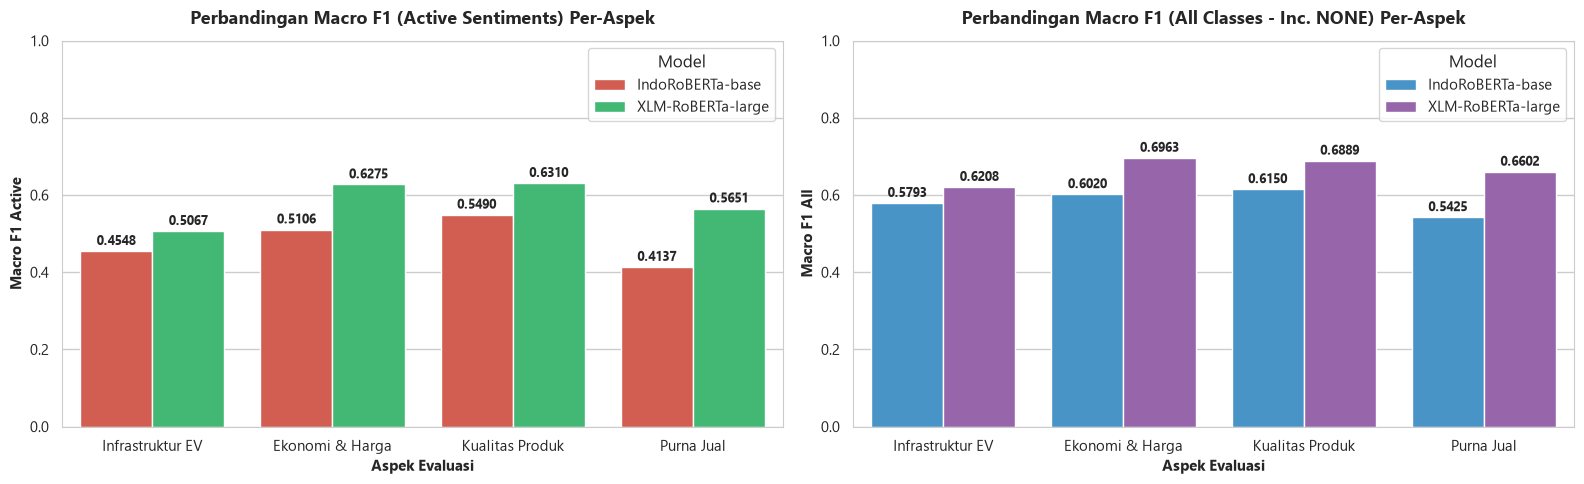

In [6]:
# Visualizing Per-Aspect Comparison (F1 Active & F1 All)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Macro F1 Active Per-Aspect
sns.barplot(
    data=df_aspects,
    x="Aspek",
    y="F1 Active",
    hue="Model",
    palette=["#e74c3c", "#2ecc71"],
    ax=axes[0]
)
axes[0].set_title("Perbandingan Macro F1 (Active Sentiments) Per-Aspek", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("Macro F1 Active", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Aspek Evaluasi", fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].legend(title="Model", frameon=True)

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{p.get_height():.4f}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 7),
                         textcoords='offset points',
                         fontsize=9, fontweight='bold')

# Subplot 2: Macro F1 All Classes Per-Aspect
sns.barplot(
    data=df_aspects,
    x="Aspek",
    y="F1 All",
    hue="Model",
    palette=["#3498db", "#9b59b6"],
    ax=axes[1]
)
axes[1].set_title("Perbandingan Macro F1 (All Classes - Inc. NONE) Per-Aspek", fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel("Macro F1 All", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Aspek Evaluasi", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].legend(title="Model", frameon=True)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.4f}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 7),
                         textcoords='offset points',
                         fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



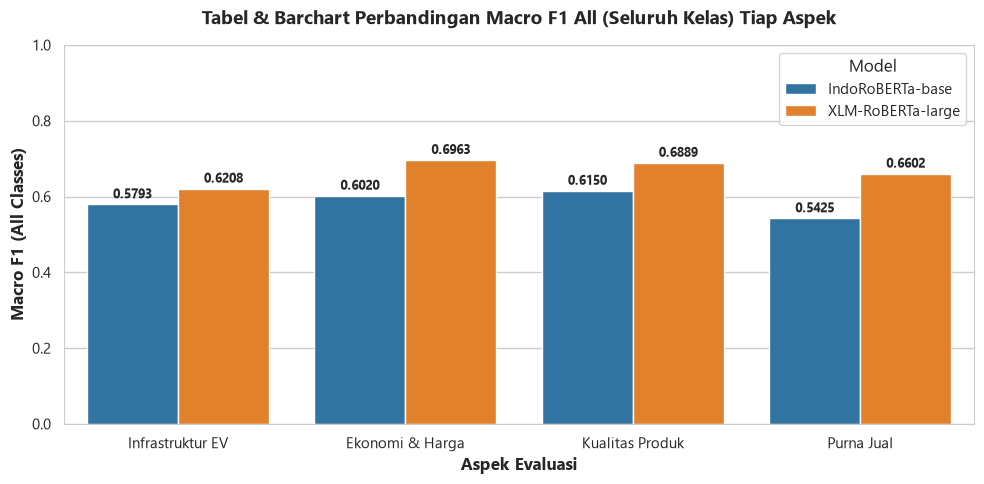

In [7]:
# Dedicated Bar Chart: Macro F1 All Classes Per-Aspect
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_aspects,
    x="Aspek",
    y="F1 All",
    hue="Model",
    palette=["#1f77b4", "#ff7f0e"],
    ax=ax
)

ax.set_title("Tabel & Barchart Perbandingan Macro F1 All (Seluruh Kelas) Tiap Aspek", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Macro F1 (All Classes)", fontsize=12, fontweight='bold')
ax.set_xlabel("Aspek Evaluasi", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(title="Model", frameon=True, facecolor='white')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 7),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



---
## 📷 3. Visualisasi Kurva Pembelajaran & Confusion Matrix XLM-RoBERTa-large

Berikut adalah grafik kurva pembelajaran (Learning Curves) dan Confusion Matrices dari model terbaik **XLM-RoBERTa-large (550M)** yang dihasilkan selama proses 5-Fold Stratified Cross-Validation.


📌 Menampilkan Kurva Pembelajaran: C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\usb_2026\outputs\iter-04\xlmroberta_learning_curves.png


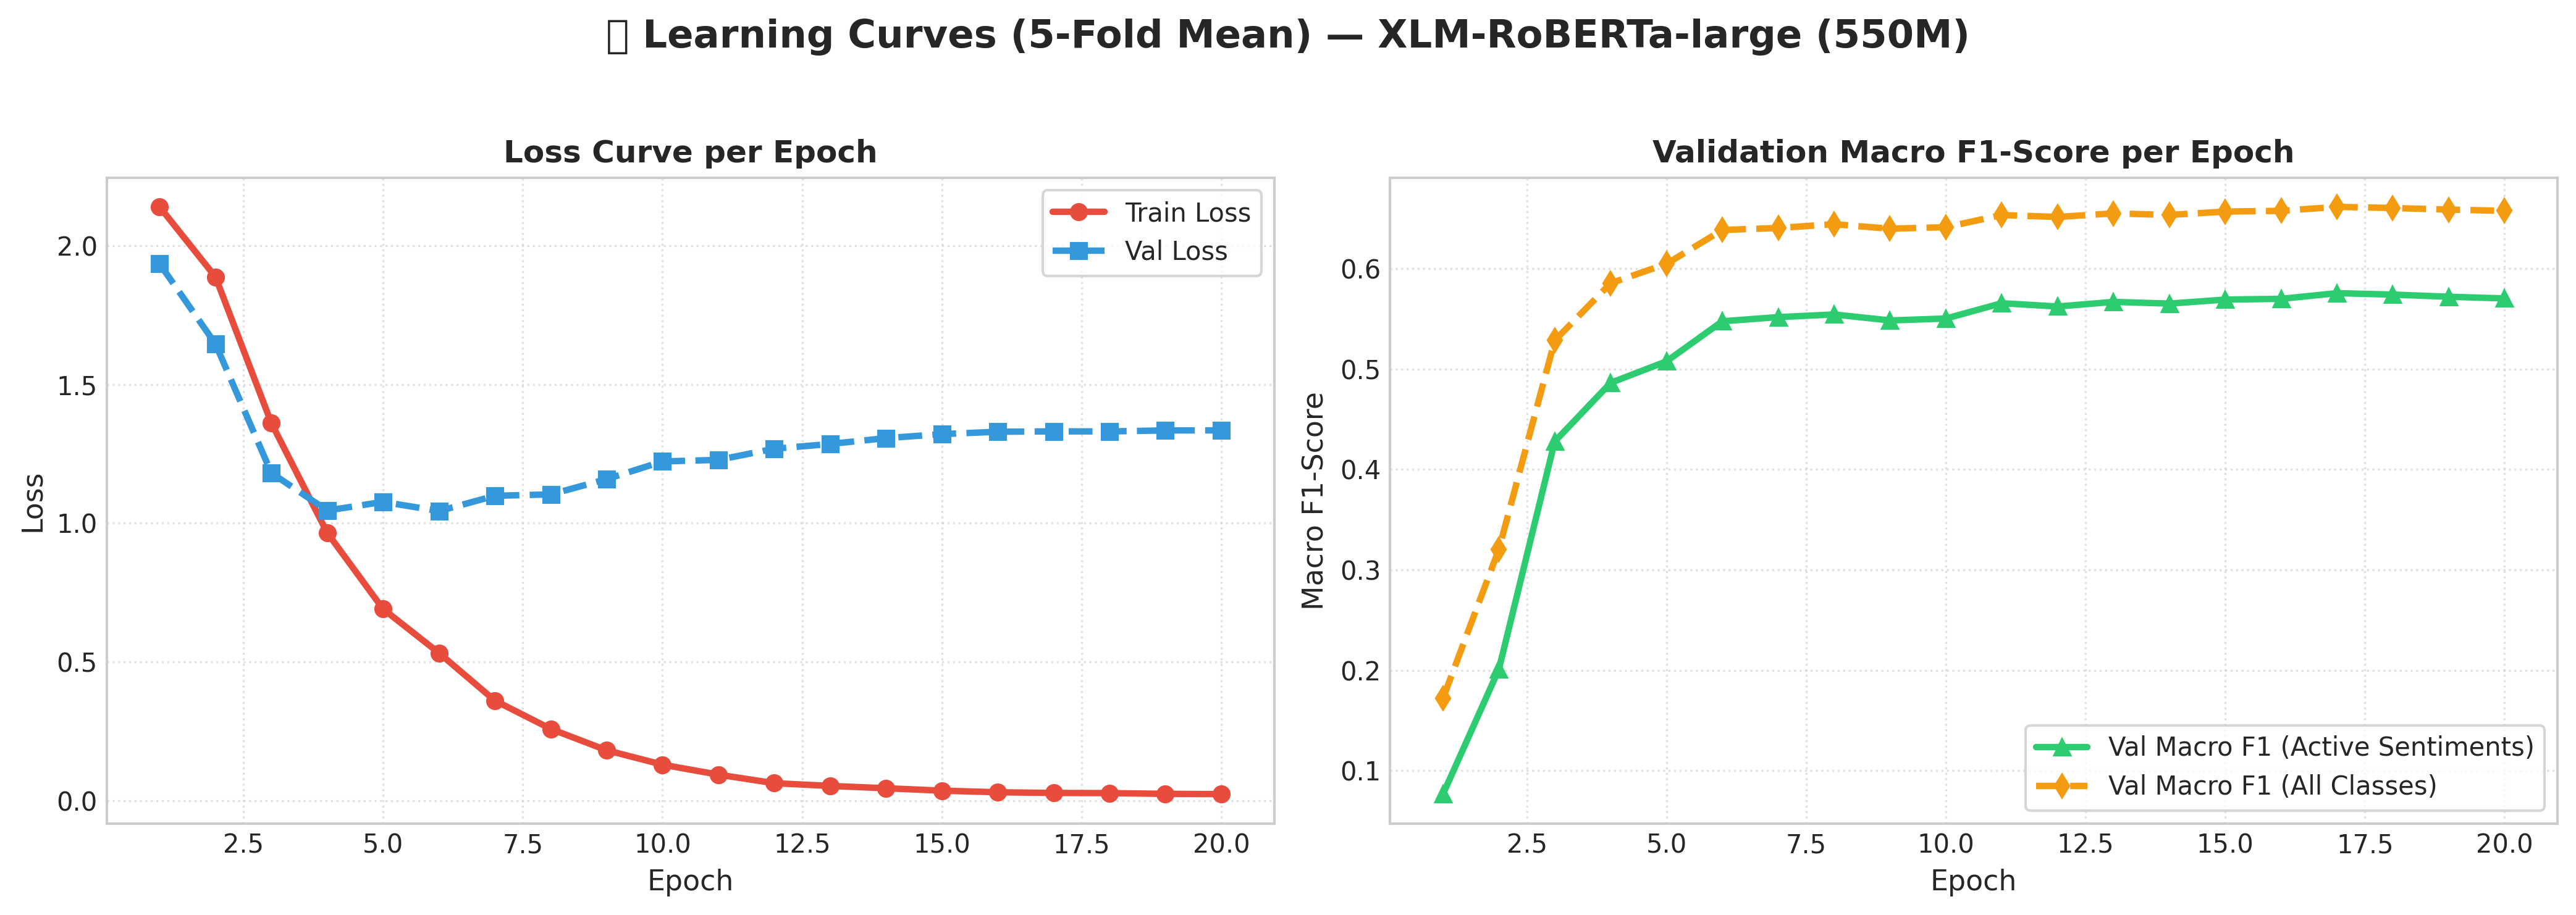

In [8]:
# Display Learning Curves Image
print(f"📌 Menampilkan Kurva Pembelajaran: {LEARNING_CURVES_IMG}")
if LEARNING_CURVES_IMG.exists():
    display(Image(filename=str(LEARNING_CURVES_IMG)))
else:
    print("❌ File kurva pembelajaran tidak ditemukan.")



📌 Menampilkan Confusion Matrices 4 Aspek: C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\usb_2026\outputs\iter-04\xlmroberta_confusion_matrices.png


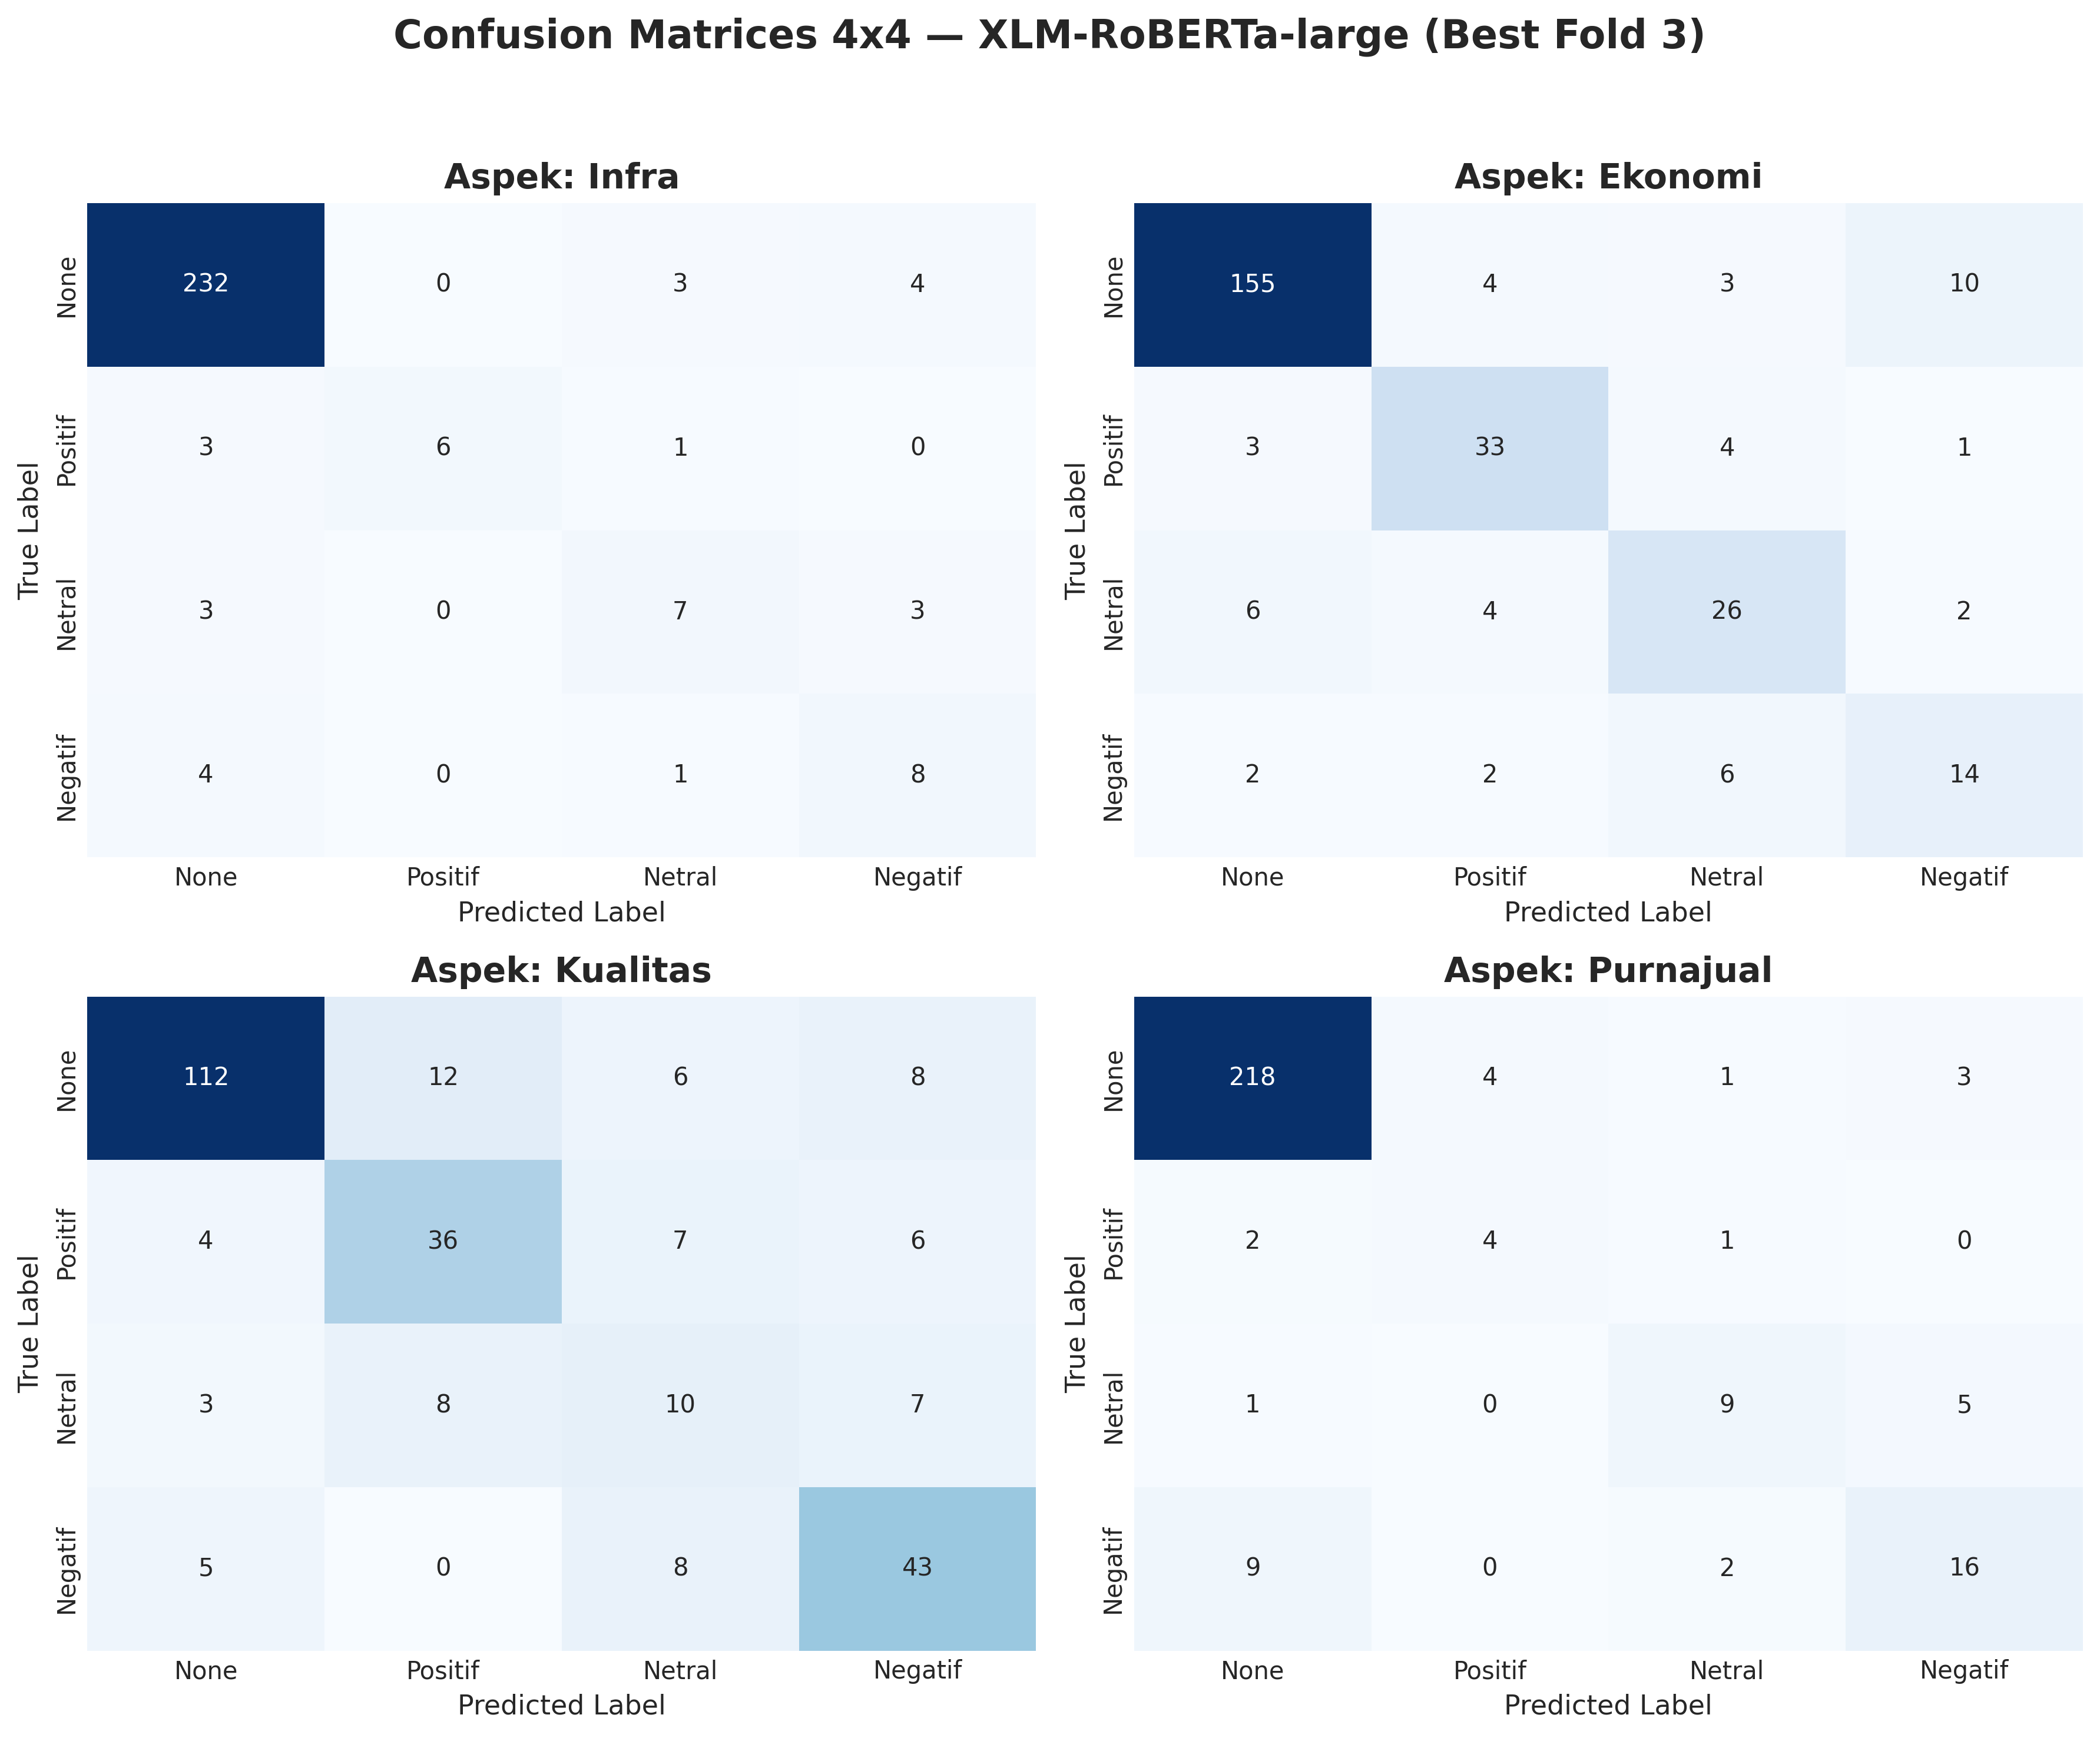

In [9]:
# Display Confusion Matrices Image
print(f"📌 Menampilkan Confusion Matrices 4 Aspek: {CONFUSION_MATRIX_IMG}")
if CONFUSION_MATRIX_IMG.exists():
    display(Image(filename=str(CONFUSION_MATRIX_IMG)))
else:
    print("❌ File confusion matrices tidak ditemukan.")



---
## 💡 4. Kesimpulan & Analisis Komparatif

1. **Keunggulan XLM-RoBERTa-large (550M):**
   - **Macro F1 (Active Sentiments):** Menunjukkan peningkatan signifikan dari **48.20%** (IndoRoBERTa-base) menjadi **58.26%** (XLM-RoBERTa-large), yaitu kenaikan sebesar **+10.05%** absolute (+20.8% relatif).
   - **Macro F1 (All Classes):** Meningkat dari **59.88%** ke **66.66%** (+6.78%).
   - **Accuracy:** Meningkat dari **78.43%** ke **83.82%** (+5.39%).

2. **Faktor Penentu Performa:**
   - Kapasitas parameter 550M pada `xlm-roberta-large` memberikan representasi konteks multilingual & Bahasa Indonesia informal (slang/YouTube comments) yang jauh lebih kuat dibandingkan `indobert-base-uncased` (110M).
   - Penerapan **Multi-Head Focal Loss ($\gamma=1.5$)** dengan **Dynamic Inverse Class Weights** dan **Threshold Adjustment** berhasil mengatasi ketidakseimbangan kelas (*class imbalance*) yang ekstrem pada dataset opini publik EV.

3. **Rekomendasi Deployment:**
   - Model **XLM-RoBERTa-large** telah dipilih dan diintegrasikan sebagai engine inferensi utama pada dashboard **SentyBoard v1.0.0** (`app.py`).
